In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, roc_curve, auc,
                             classification_report, ConfusionMatrixDisplay)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_columns', None)
np.random.seed(42)

In [2]:
df = pd.read_csv('mental-heath.csv')
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")

Shape: 1433 rows × 63 columns


In [3]:
df.head()

,Are you self-employed?,How many employees does your company or organization have?,Is your employer primarily a tech company/organization?,Is your primary role within your company related to tech/IT?,Does your employer provide mental health benefits as part of healthcare coverage?,Do you know the options for mental health care available under your employer-provided coverage?,"Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)?",Does your employer offer resources to learn more about mental health concerns and options for seeking help?,Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?,"If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:",Do you think that discussing a mental health disorder with your employer would have negative consequences?,Do you think that discussing a physical health issue with your employer would have negative consequences?,Would you feel comfortable discussing a mental health disorder with your coworkers?,Would you feel comfortable discussing a mental health disorder with your direct supervisor(s)?,Do you feel that your employer takes mental health as seriously as physical health?,Have you heard of or observed negative consequences for co-workers who have been open about mental health issues in your workplace?,Do you have medical coverage (private insurance or state-provided) which includes treatment of mental health issues?,Do you know local or online resources to seek help for a mental health disorder?,"If you have been diagnosed or treated for a mental health disorder, do you ever reveal this to clients or business contacts?","If you have revealed a mental health issue to a client or business contact, do you believe this has impacted you negatively?","If you have been diagnosed or treated for a mental health disorder, do you ever reveal this to coworkers or employees?","If you have revealed a mental health issue to a coworker or employee, do you believe this has impacted you negatively?",Do you believe your productivity is ever affected by a mental health issue?,"If yes, what percentage of your work time (time performing primary or secondary job functions) is affected by a mental health issue?",Do you have previous employers?,Have your previous employers provided mental health benefits?,Were you aware of the options for mental health care provided by your previous employers?,Did your previous employers ever formally discuss mental health (as part of a wellness campaign or other official communication)?,Did your previous employers provide resources to learn more about mental health issues and how to seek help?,Was your anonymity protected if you chose to take advantage of mental health or substance abuse treatment resources with previous employers?,Do you think that discussing a mental health disorder with previous employers would have negative consequences?,Do you think that discussing a physical health issue with previous employers would have negative consequences?,Would you have been willing to discuss a mental health issue with your previous co-workers?,Would you have been willing to discuss a mental health issue with your direct supervisor(s)?,Did you feel that your previous employers took mental health as seriously as physical health?,Did you hear of or observe negative consequences for co-workers with mental health issues in your previous workplaces?,Would you be willing to bring up a physical health issue with a potential employer in an interview?,Why or why not?,Would you bring up a mental health issue with a potential employer in an interview?,Why or why not?.1,Do you feel that being identified as a person with a mental health issue would hurt your career?,Do you think that team members/co-workers would view you more negatively if they knew you suffered from a menta

In [4]:
df.tail(10)

,Are you self-employed?,How many employees does your company or organization have?,Is your employer primarily a tech company/organization?,Is your primary role within your company related to tech/IT?,Does your employer provide mental health benefits as part of healthcare coverage?,Do you know the options for mental health care available under your employer-provided coverage?,"Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)?",Does your employer offer resources to learn more about mental health concerns and options for seeking help?,Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?,"If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:",Do you think that discussing a mental health disorder with your employer would have negative consequences?,Do you think that discussing a physical health issue with your employer would have negative consequences?,Would you feel comfortable discussing a mental health disorder with your coworkers?,Would you feel comfortable discussing a mental health disorder with your direct supervisor(s)?,Do you feel that your employer takes mental health as seriously as physical health?,Have you heard of or observed negative consequences for co-workers who have been open about mental health issues in your workplace?,Do you have medical coverage (private insurance or state-provided) which includes treatment of mental health issues?,Do you know local or online resources to seek help for a mental health disorder?,"If you have been diagnosed or treated for a mental health disorder, do you ever reveal this to clients or business contacts?","If you have revealed a mental health issue to a client or business contact, do you believe this has impacted you negatively?","If you have been diagnosed or treated for a mental health disorder, do you ever reveal this to coworkers or employees?","If you have revealed a mental health issue to a coworker or employee, do you believe this has impacted you negatively?",Do you believe your productivity is ever affected by a mental health issue?,"If yes, what percentage of your work time (time performing primary or secondary job functions) is affected by a mental health issue?",Do you have previous employers?,Have your previous employers provided mental health benefits?,Were you aware of the options for mental health care provided by your previous employers?,Did your previous employers ever formally discuss mental health (as part of a wellness campaign or other official communication)?,Did your previous employers provide resources to learn more about mental health issues and how to seek help?,Was your anonymity protected if you chose to take advantage of mental health or substance abuse treatment resources with previous employers?,Do you think that discussing a mental health disorder with previous employers would have negative consequences?,Do you think that discussing a physical health issue with previous employers would have negative consequences?,Would you have been willing to discuss a mental health issue with your previous co-workers?,Would you have been willing to discuss a mental health issue with your direct supervisor(s)?,Did you feel that your previous employers took mental health as seriously as physical health?,Did you hear of or observe negative consequences for co-workers with mental health issues in your previous workplaces?,Would you be willing to bring up a physical health issue with a potential employer in an interview?,Why or why not?,Would you bring up a mental health issue with a potential employer in an interview?,Why or why not?.1,Do you feel that being identified as a person with a mental health issue would hurt your career?,Do you think that team members/co-workers would view you more negatively if they knew you suffered from a menta

In [5]:
df.sample(70)

,Are you self-employed?,How many employees does your company or organization have?,Is your employer primarily a tech company/organization?,Is your primary role within your company related to tech/IT?,Does your employer provide mental health benefits as part of healthcare coverage?,Do you know the options for mental health care available under your employer-provided coverage?,"Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)?",Does your employer offer resources to learn more about mental health concerns and options for seeking help?,Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?,"If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:",Do you think that discussing a mental health disorder with your employer would have negative consequences?,Do you think that discussing a physical health issue with your employer would have negative consequences?,Would you feel comfortable discussing a mental health disorder with your coworkers?,Would you feel comfortable discussing a mental health disorder with your direct supervisor(s)?,Do you feel that your employer takes mental health as seriously as physical health?,Have you heard of or observed negative consequences for co-workers who have been open about mental health issues in your workplace?,Do you have medical coverage (private insurance or state-provided) which includes treatment of mental health issues?,Do you know local or online resources to seek help for a mental health disorder?,"If you have been diagnosed or treated for a mental health disorder, do you ever reveal this to clients or business contacts?","If you have revealed a mental health issue to a client or business contact, do you believe this has impacted you negatively?","If you have been diagnosed or treated for a mental health disorder, do you ever reveal this to coworkers or employees?","If you have revealed a mental health issue to a coworker or employee, do you believe this has impacted you negatively?",Do you believe your productivity is ever affected by a mental health issue?,"If yes, what percentage of your work time (time performing primary or secondary job functions) is affected by a mental health issue?",Do you have previous employers?,Have your previous employers provided mental health benefits?,Were you aware of the options for mental health care provided by your previous employers?,Did your previous employers ever formally discuss mental health (as part of a wellness campaign or other official communication)?,Did your previous employers provide resources to learn more about mental health issues and how to seek help?,Was your anonymity protected if you chose to take advantage of mental health or substance abuse treatment resources with previous employers?,Do you think that discussing a mental health disorder with previous employers would have negative consequences?,Do you think that discussing a physical health issue with previous employers would have negative consequences?,Would you have been willing to discuss a mental health issue with your previous co-workers?,Would you have been willing to discuss a mental health issue with your direct supervisor(s)?,Did you feel that your previous employers took mental health as seriously as physical health?,Did you hear of or observe negative consequences for co-workers with mental health issues in your previous workplaces?,Would you be willing to bring up a physical health issue with a potential employer in an interview?,Why or why not?,Would you bring up a mental health issue with a potential employer in an interview?,Why or why not?.1,Do you feel that being identified as a person with a mental health issue would hurt your career?,Do you think that team members/co-workers would view you more negatively if they knew you suffered from a menta

In [6]:
df_raw = pd.read_csv('mental-heath.csv')

In [7]:
keep = []
drop_reasons = {}

for col in df_raw.columns:
    
    # RULE 1: Drop if >40% missing
    missing = df_raw[col].isnull().mean()
    if missing > 0.40:
        drop_reasons[col] = f"DROPPED — {missing*100:.0f}% missing"
        continue
    
    # RULE 2: Drop if free text (too many unique values to model)
    n_unique = df_raw[col].nunique()
    if n_unique > 50:
        drop_reasons[col] = f"DROPPED — free text ({n_unique} unique values)"
        continue
    
    # RULE 3: Drop if it's a previous/past employer duplicate
    if 'previous employer' in col.lower() or 'past employer' in col.lower():
        drop_reasons[col] = "DROPPED — duplicate (previous employer version)"
        continue

    keep.append(col)

print(f"KEEP ({len(keep)} columns):")
for c in keep: print(f" {c}")

print(f"\nDROP ({len(drop_reasons)} columns):")
for c, reason in drop_reasons.items(): print(f" {c[:70]} → {reason}")

KEEP (32 columns):
 Are you self-employed?
 How many employees does your company or organization have?
 Is your employer primarily a tech company/organization?
 Does your employer provide mental health benefits as part of healthcare coverage?
 Do you know the options for mental health care available under your employer-provided coverage?
 Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)?
 Does your employer offer resources to learn more about mental health concerns and options for seeking help?
 Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?
 If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:
 Do you think that discussing a mental health disorder with your employer would have negative consequences?
 Do you think that discussing a physical health issue 

In [8]:
rename_map = {
    'Are you self-employed?': 'self_employed',
    'How many employees does your company or organization have?': 'num_employees',
    'Is your employer primarily a tech company/organization?': 'tech_company',
    'Is your primary role within your company related to tech/IT?': 'tech_role',
    'Does your employer provide mental health benefits as part of healthcare coverage?': 'benefits',
    'Do you know the options for mental health care available under your employer-provided coverage?': 'care_options',
    'Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)?': 'wellness_program',
    'Does your employer offer resources to learn more about mental health concerns and options for seeking help?': 'seek_help',
    'Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?': 'anonymity',
    'If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:': 'leave',
    'Do you think that discussing a mental health disorder with your employer would have negative consequences?': 'mh_consequence',
    'Do you think that discussing a physical health issue with your employer would have negative consequences?': 'ph_consequence',
    'Would you feel comfortable discussing a mental health disorder with your coworkers?': 'coworkers',
    'Would you feel comfortable discussing a mental health disorder with your direct supervisor(s)?': 'supervisor',
    'Do you feel that your employer takes mental health as seriously as physical health?': 'mh_vs_ph',
    'Have you heard of or observed negative consequences for co-workers who have been open about mental health issues in your workplace?': 'obs_consequence',
    'Do you have previous employers?': 'prev_employer',
    'Would you be willing to bring up a physical health issue with a potential employer in an interview?': 'ph_interview',
    'Would you bring up a mental health issue with a potential employer in an interview?': 'mh_interview',
    'Do you feel that being identified as a person with a mental health issue would hurt your career?': 'career_impact',
    'Do you think that team members/co-workers would view you more negatively if they knew you suffered from a mental health issue?': 'team_view',
    'How willing would you be to share with friends and family that you have a mental illness?': 'share_family',
    'Do you have a family history of mental illness?': 'family_history',
    'Have you had a mental health disorder in the past?': 'past_disorder',
    'Do you currently have a mental health disorder?': 'current_disorder',
    'Have you ever sought treatment for a mental health issue from a mental health professional?': 'treatment',
    'If you have a mental health issue, do you feel that it interferes with your work when being treated effectively?': 'work_interfere_treated',
    'If you have a mental health issue, do you feel that it interferes with your work when NOT being treated effectively?': 'work_interfere_untreated',
    'What is your age?': 'age',
    'What is your gender?': 'gender',
    'What country do you live in?': 'country',
    'What US state or territory do you live in?': 'us_state',
    'Which of the following best describes your work position?': 'work_position',
    'Do you work remotely?': 'remote_work'
}
df = df.rename(columns=rename_map)

In [9]:
df = df[list(rename_map.values())]
print(f"After trimming: {df.shape}")
df.columns.tolist()

After trimming: (1433, 34)


['self_employed',
 'num_employees',
 'tech_company',
 'tech_role',
 'benefits',
 'care_options',
 'wellness_program',
 'seek_help',
 'anonymity',
 'leave',
 'mh_consequence',
 'ph_consequence',
 'coworkers',
 'supervisor',
 'mh_vs_ph',
 'obs_consequence',
 'prev_employer',
 'ph_interview',
 'mh_interview',
 'career_impact',
 'team_view',
 'share_family',
 'family_history',
 'past_disorder',
 'current_disorder',
 'treatment',
 'work_interfere_treated',
 'work_interfere_untreated',
 'age',
 'gender',
 'country',
 'us_state',
 'work_position',
 'remote_work']

Target column: 'treatment'
treatment
1    839
0    594
Name: count, dtype: int64

Class balance: 58.5% sought treatment


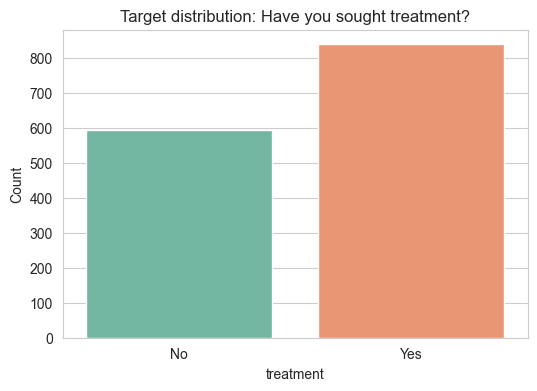

In [10]:
print("Target column: 'treatment'")
print(df['treatment'].value_counts())
print(f"\nClass balance: {df['treatment'].mean()*100:.1f}% sought treatment")

plt.figure(figsize=(6,4))
sns.countplot(x='treatment', data=df, palette='Set2')
plt.title('Target distribution: Have you sought treatment?')
plt.xticks([0,1], ['No', 'Yes'])
plt.ylabel('Count')
plt.show()

                  missing_count  missing_pct
tech_role                  1170         81.6
us_state                    593         41.4
care_options                420         29.3
num_employees               287         20.0
mh_consequence              287         20.0
tech_company                287         20.0
wellness_program            287         20.0
seek_help                   287         20.0
anonymity                   287         20.0
benefits                    287         20.0
mh_vs_ph                    287         20.0
ph_consequence              287         20.0
coworkers                   287         20.0
supervisor                  287         20.0
leave                       287         20.0
obs_consequence             287         20.0
gender                        3          0.2


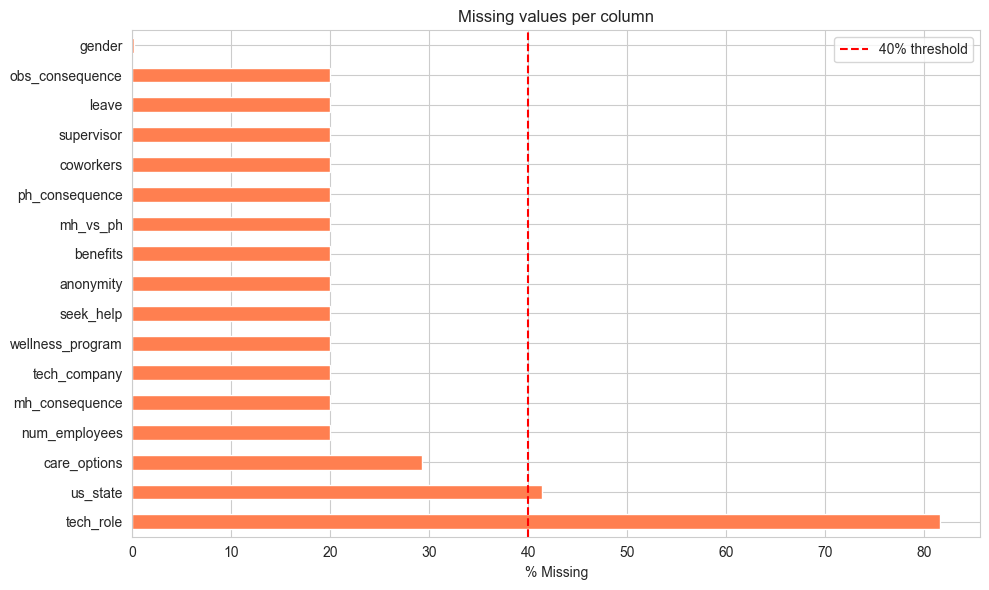

In [11]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_df = missing_df[missing_df['missing_count'] > 0]
print(missing_df)

plt.figure(figsize=(10,6))
missing_pct[missing_pct > 0].plot(kind='barh', color='coral')
plt.axvline(40, color='red', linestyle='--', label='40% threshold')
plt.xlabel('% Missing')
plt.title('Missing values per column')
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
# Dropping the columns where more than 40% of values are missing
threshold = 0.4
cols_to_drop = missing_df[missing_df['missing_pct'] > threshold*100].index.tolist()
print(f"Dropping {len(cols_to_drop)} high-missing columns:")
for c in cols_to_drop: print(f"  - {c}")

df = df.drop(columns=cols_to_drop)
print(f"\nRemaining shape: {df.shape}")

Dropping 2 high-missing columns:
  - tech_role
  - us_state

Remaining shape: (1433, 32)


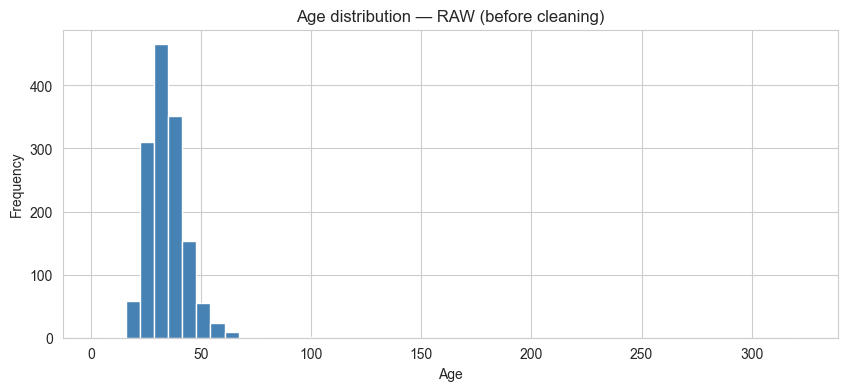

Min age: 3
Max age: 323
Suspicious values (< 15 or > 80): 3 rows
age
99     1
323    1
Name: count, dtype: int64
age
3    1
Name: count, dtype: int64


In [13]:
plt.figure(figsize=(10, 4))
df['age'].plot(kind='hist', bins=50, color='steelblue')
plt.title('Age distribution — RAW (before cleaning)')
plt.xlabel('Age')
plt.show()

print(f"Min age: {df['age'].min()}")
print(f"Max age: {df['age'].max()}")
print(f"Suspicious values (< 15 or > 80): {((df['age'] < 15) | (df['age'] > 80)).sum()} rows")
print(df[df['age'] > 80]['age'].value_counts().head())
print(df[df['age'] < 15]['age'].value_counts().head())

Before cleaning:
  min=3, max=323, mean=34.3
  Values outside [15, 80]: 3

After cleaning:
  min=15.0, max=74.0, mean=34.1


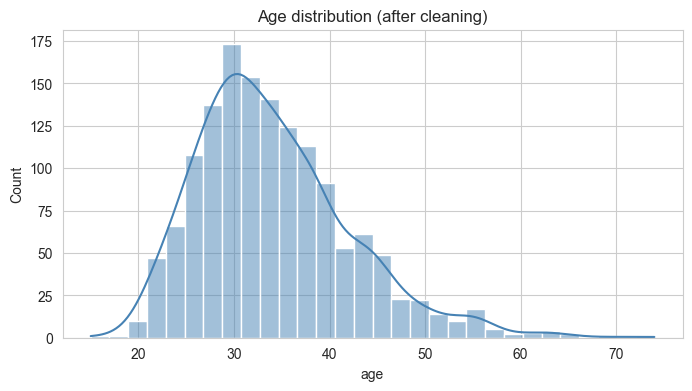

In [14]:
print("Before cleaning:")
print(f"  min={df['age'].min()}, max={df['age'].max()}, mean={df['age'].mean():.1f}")
print(f"  Values outside [15, 80]: {((df['age']<15) | (df['age']>80)).sum()}")

# Working-age sanity bounds: 15–80. Anything outside = data entry error.
df.loc[(df['age'] < 15) | (df['age'] > 80), 'age'] = np.nan
df['age'] = df['age'].fillna(df['age'].median())

print("\nAfter cleaning:")
print(f"  min={df['age'].min()}, max={df['age'].max()}, mean={df['age'].mean():.1f}")

plt.figure(figsize=(8,4))
sns.histplot(df['age'], bins=30, kde=True, color='steelblue')
plt.title('Age distribution (after cleaning)')
plt.show()

In [15]:
print(f"Unique gender values: {df['gender'].nunique()}")
print("\nAll raw gender values:")
print(df['gender'].value_counts().to_string())

Unique gender values: 70

All raw gender values:
gender
Male                                                                                                                                                             610
male                                                                                                                                                             249
Female                                                                                                                                                           153
female                                                                                                                                                            95
M                                                                                                                                                                 86
m                                                                                                                      

In [16]:
print(f"Unique gender values before cleaning: {df['gender'].nunique()}")
print("Sample raw values:", df['gender'].dropna().unique()[:15])

def normalize_gender(g):
    if pd.isna(g): return np.nan
    g = str(g).strip().lower()
    male_tokens = ['male', 'm', 'man', 'cis male', 'cis man', 'sir', 'mail', 'malr', 'dude']
    female_tokens = ['female', 'f', 'woman', 'cis female', 'cis woman', 'femail', 'femake']
    if any(tok == g or tok in g for tok in female_tokens) and 'male' not in g.split():
        # careful: 'female' contains 'male', so check female first
        return 'Female'
    if any(tok == g or tok in g for tok in male_tokens):
        return 'Male'
    if 'female' in g or 'woman' in g:
        return 'Female'
    return 'Other'

df['gender'] = df['gender'].apply(normalize_gender)
df['gender'] = df['gender'].fillna('Other')
print("\nAfter cleaning:")
print(df['gender'].value_counts())

Unique gender values before cleaning: 70
Sample raw values: <StringArray>
[                     'Male',                      'male',
                     'Male ',                    'Female',
                         'M',                    'female',
                         'm',     'I identify as female.',
                   'female ',                  'Bigender',
                'non-binary', 'Female assigned at birth ',
                         'F',                     'Woman',
                       'man']
Length: 15, dtype: str

After cleaning:
gender
Male      1062
Female     352
Other       19
Name: count, dtype: int64


In [17]:
for col in df.columns:
    if df[col].isnull().any():
        mode = df[col].mode()[0]
        df[col] = df[col].fillna(mode)

print(f"Missing values remaining: {df.isnull().sum().sum()}")
print(f"Shape: {df.shape}")

Missing values remaining: 0
Shape: (1433, 32)


% who sought treatment, split by family history:
treatment          0     1
family_history            
I don't know    42.9  57.1
No              66.8  33.2
Yes             22.4  77.6


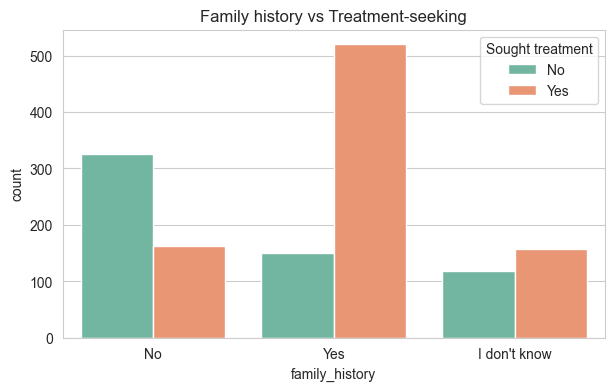

In [18]:
ct = pd.crosstab(df['family_history'], df['treatment'], normalize='index') * 100
print("% who sought treatment, split by family history:")
print(ct.round(1))

plt.figure(figsize=(7,4))
sns.countplot(x='family_history', hue='treatment', data=df, palette='Set2')
plt.title('Family history vs Treatment-seeking')
plt.legend(title='Sought treatment', labels=['No','Yes'])
plt.show()

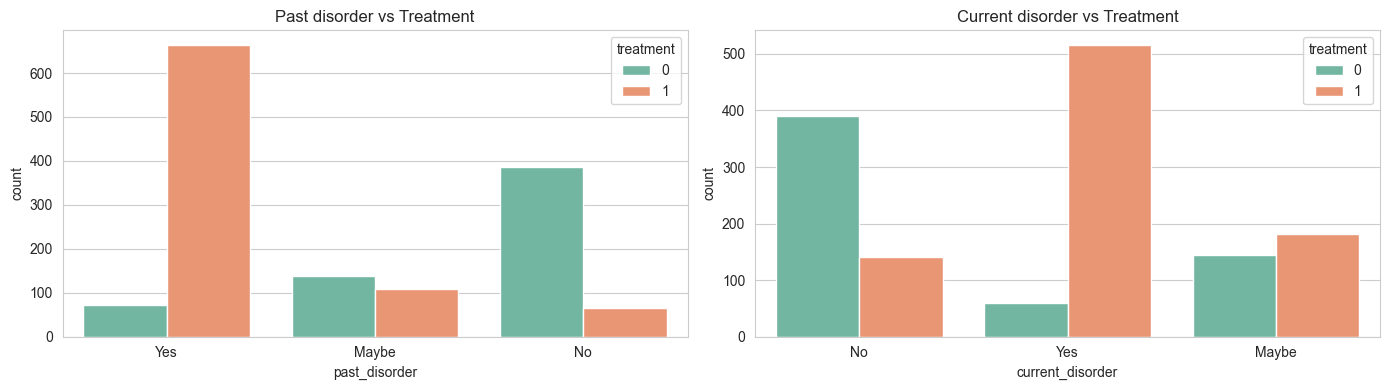


past_disorder:
treatment         0     1
past_disorder            
Maybe          55.7  44.3
No             85.4  14.6
Yes             9.8  90.2

current_disorder:
treatment            0     1
current_disorder            
Maybe             44.3  55.7
No                73.4  26.6
Yes               10.3  89.7


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14,4))
sns.countplot(x='past_disorder', hue='treatment', data=df, ax=axes[0], palette='Set2')
axes[0].set_title('Past disorder vs Treatment')
sns.countplot(x='current_disorder', hue='treatment', data=df, ax=axes[1], palette='Set2')
axes[1].set_title('Current disorder vs Treatment')
plt.tight_layout()
plt.show()

for col in ['past_disorder', 'current_disorder']:
    ct = pd.crosstab(df[col], df['treatment'], normalize='index') * 100
    print(f"\n{col}:"); print(ct.round(1))

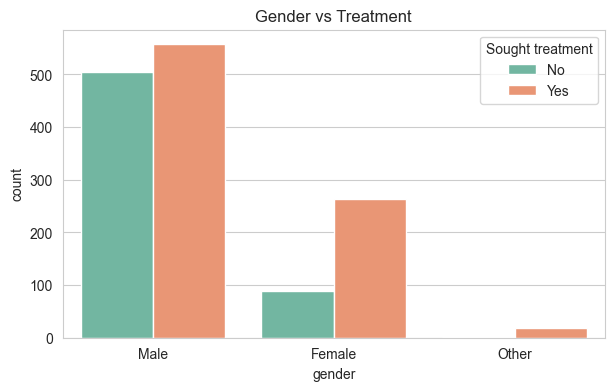

treatment     0     1
gender               
Female     25.0  75.0
Male       47.6  52.4
Other       5.3  94.7


In [20]:
plt.figure(figsize=(7,4))
sns.countplot(x='gender', hue='treatment', data=df, palette='Set2')
plt.title('Gender vs Treatment')
plt.legend(title='Sought treatment', labels=['No','Yes'])
plt.show()

ct = pd.crosstab(df['gender'], df['treatment'], normalize='index') * 100
print(ct.round(1))

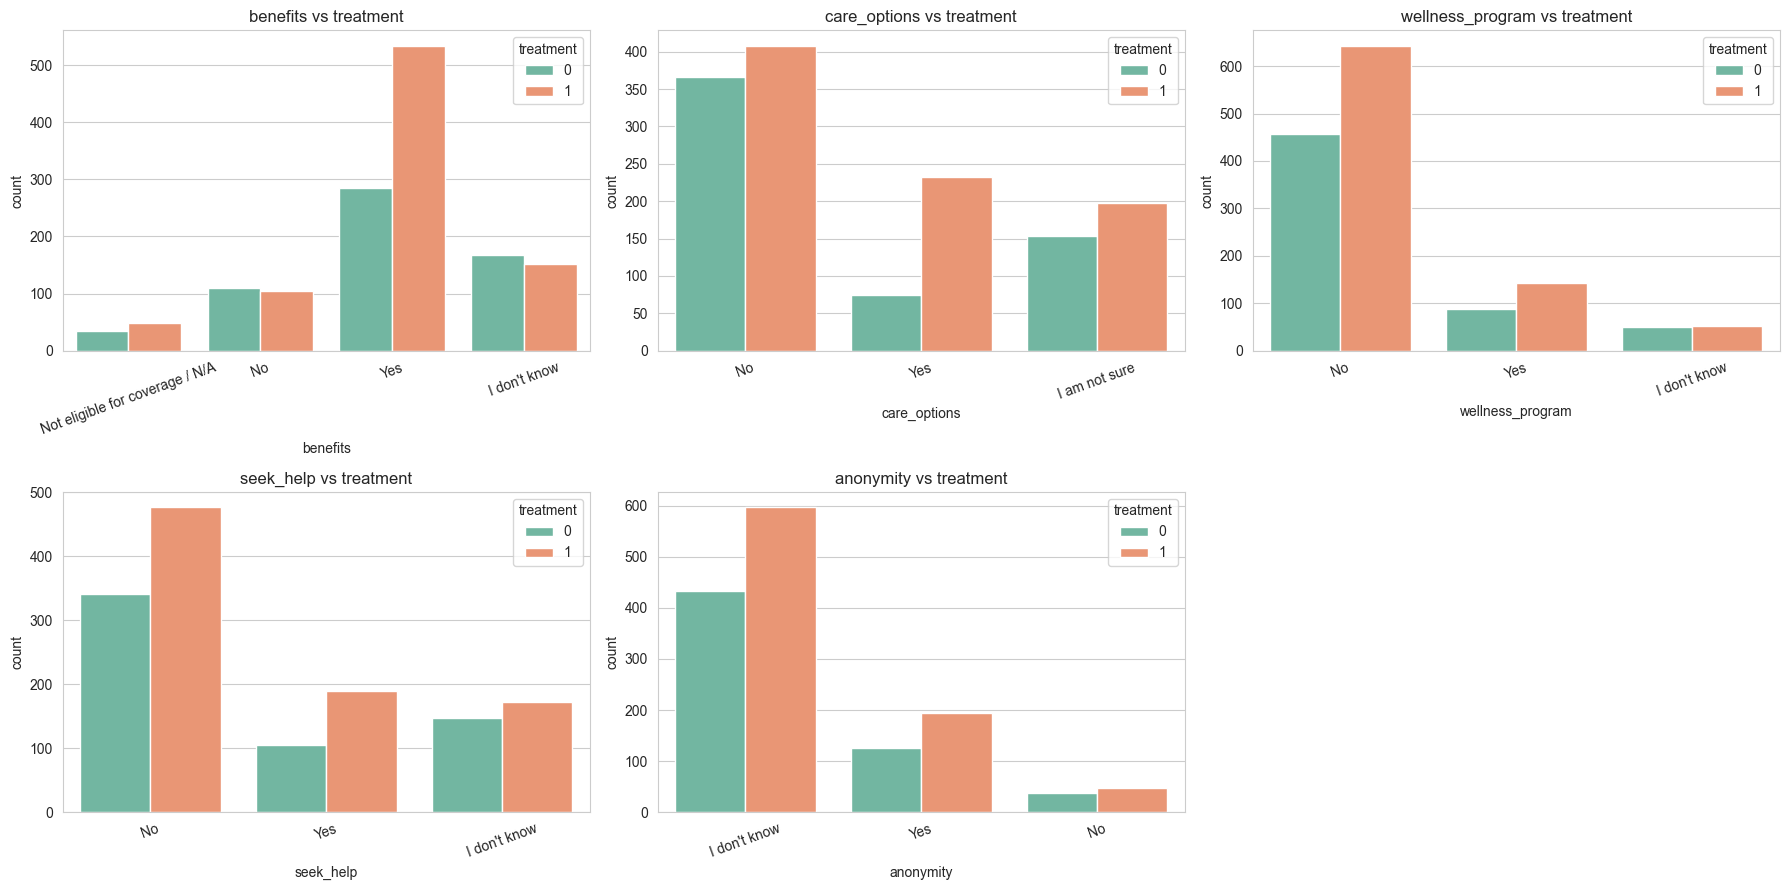

In [21]:
workplace_cols = ['benefits', 'care_options', 'wellness_program', 'seek_help', 'anonymity']
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.flatten()
for i, col in enumerate(workplace_cols):
    sns.countplot(x=col, hue='treatment', data=df, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{col} vs treatment')
    axes[i].tick_params(axis='x', rotation=20)
axes[-1].axis('off')
plt.tight_layout()
plt.show()

In [22]:
df_enc = df.copy()

for col in df_enc.columns:
    if not pd.api.types.is_numeric_dtype(df_enc[col]):
        le = LabelEncoder()
        df_enc[col] = le.fit_transform(df_enc[col].astype(str)).astype(int)

df_enc = df_enc.apply(pd.to_numeric, errors='coerce')
df_enc = df_enc.fillna(0)

print(df_enc.dtypes.value_counts())
print("Strings remaining:", df_enc.select_dtypes(include=['object']).columns.tolist())
print(df_enc.shape)

int64      30
float64     2
Name: count, dtype: int64
Strings remaining: []
(1433, 32)


Features ranked by absolute correlation with target:
past_disorder               0.504
work_interfere_treated      0.474
work_interfere_untreated    0.348
current_disorder            0.345
family_history              0.244
share_family                0.228
benefits                    0.162
gender                     -0.160
care_options                0.128
career_impact               0.124
country                     0.120
prev_employer               0.083
obs_consequence             0.076
team_view                   0.074
age                         0.071
seek_help                   0.071
mh_interview                0.054
self_employed               0.049
wellness_program            0.047
mh_vs_ph                   -0.036
ph_interview               -0.036
anonymity                   0.022
work_position               0.016
ph_consequence              0.016
mh_consequence              0.015
tech_company                0.011
leave                      -0.011
coworkers                   0

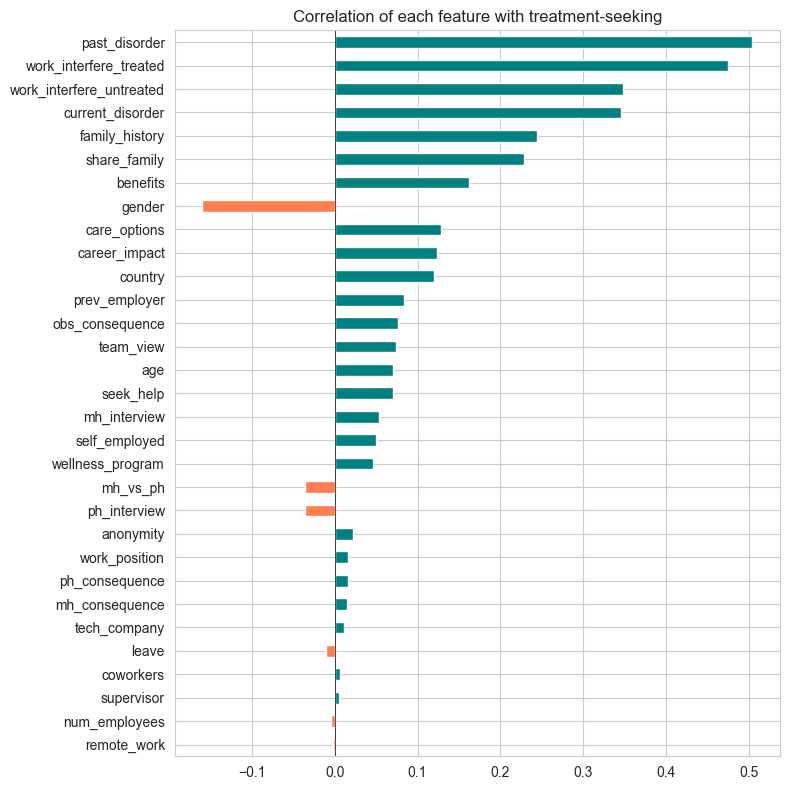

In [23]:
target_corr = df_enc.corr()['treatment'].drop('treatment').sort_values(key=abs, ascending=False)
print("Features ranked by absolute correlation with target:")
print(target_corr.round(3))

plt.figure(figsize=(8,8))
target_corr.plot(kind='barh', color=['teal' if v>0 else 'coral' for v in target_corr])
plt.title('Correlation of each feature with treatment-seeking')
plt.axvline(0, color='black', linewidth=0.5)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [24]:
X = df_enc.drop('treatment', axis=1)
y = df_enc['treatment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train target balance: {y_train.mean():.2f} | Test target balance: {y_test.mean():.2f}")

Train: (1146, 31), Test: (287, 31)
Train target balance: 0.59 | Test target balance: 0.59


In [25]:
results = {}

def evaluate(name, model, X_tr, y_tr, X_te, y_te, needs_scale=False):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1] if hasattr(model, 'predict_proba') else model.decision_function(X_te)
    results[name] = {
        'model': model,
        'y_pred': y_pred,
        'y_proba': y_proba,
        'accuracy': accuracy_score(y_te, y_pred),
        'precision': precision_score(y_te, y_pred),
        'recall': recall_score(y_te, y_pred),
        'f1': f1_score(y_te, y_pred),
    }
    print(f"=== {name} ===")
    print(f"  Accuracy : {results[name]['accuracy']:.4f}")
    print(f"  Precision: {results[name]['precision']:.4f}")
    print(f"  Recall   : {results[name]['recall']:.4f}")
    print(f"  F1       : {results[name]['f1']:.4f}\n")

# 1. Logistic Regression 
evaluate('Logistic Regression', LogisticRegression(max_iter=1000, random_state=42),
         X_train_scaled, y_train, X_test_scaled, y_test)

# 2. Decision Tree
evaluate('Decision Tree', DecisionTreeClassifier(max_depth=8, random_state=42),
         X_train, y_train, X_test, y_test)

# 3. Random Forest
evaluate('Random Forest', RandomForestClassifier(n_estimators=200, random_state=42),
         X_train, y_train, X_test, y_test)

# 4. XGBoost
evaluate('XGBoost', XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.1,
                                   use_label_encoder=False, eval_metric='logloss', random_state=42),
         X_train, y_train, X_test, y_test)

# 5. SVM 
evaluate('SVM', SVC(kernel='rbf', probability=True, random_state=42),
         X_train_scaled, y_train, X_test_scaled, y_test)

=== Logistic Regression ===
  Accuracy : 0.7909
  Precision: 0.8418
  Recall   : 0.7917
  F1       : 0.8160

=== Decision Tree ===
  Accuracy : 0.8153
  Precision: 0.8616
  Recall   : 0.8155
  F1       : 0.8379

=== Random Forest ===
  Accuracy : 0.8328
  Precision: 0.8409
  Recall   : 0.8810
  F1       : 0.8605

=== XGBoost ===
  Accuracy : 0.7979
  Precision: 0.8090
  Recall   : 0.8571
  F1       : 0.8324

=== SVM ===
  Accuracy : 0.8014
  Precision: 0.8323
  Recall   : 0.8274
  F1       : 0.8299



                     Accuracy  Precision  Recall      F1
Logistic Regression    0.7909     0.8418  0.7917  0.8160
Decision Tree          0.8153     0.8616  0.8155  0.8379
Random Forest          0.8328     0.8409  0.8810  0.8605
XGBoost                0.7979     0.8090  0.8571  0.8324
SVM                    0.8014     0.8323  0.8274  0.8299


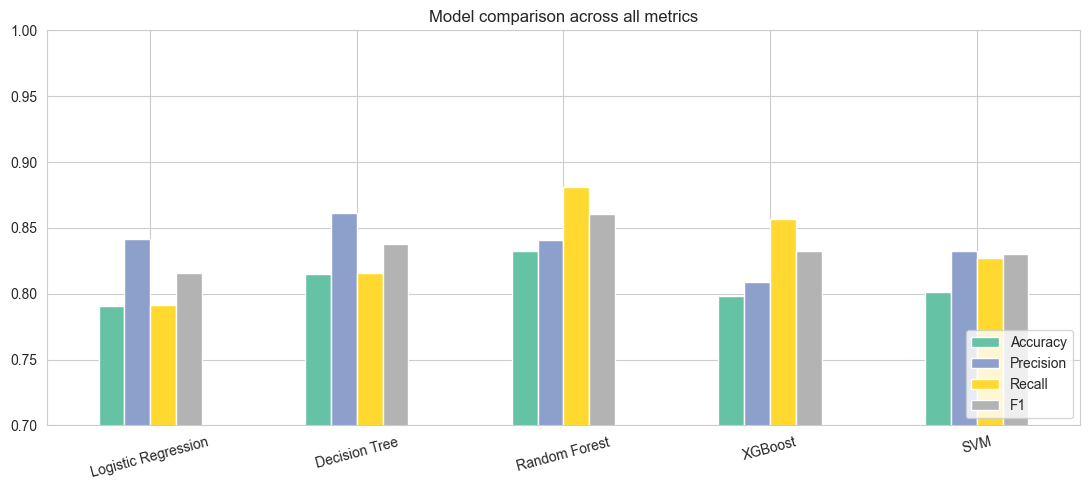

In [26]:
summary = pd.DataFrame({
    name: {'Accuracy': r['accuracy'], 'Precision': r['precision'],
           'Recall': r['recall'], 'F1': r['f1']}
    for name, r in results.items()
}).T.round(4)

print(summary)
summary.plot(kind='bar', figsize=(11,5), colormap='Set2')
plt.title('Model comparison across all metrics')
plt.xticks(rotation=15); plt.ylim(0.7, 1.0)
plt.legend(loc='lower right'); plt.tight_layout(); plt.show()

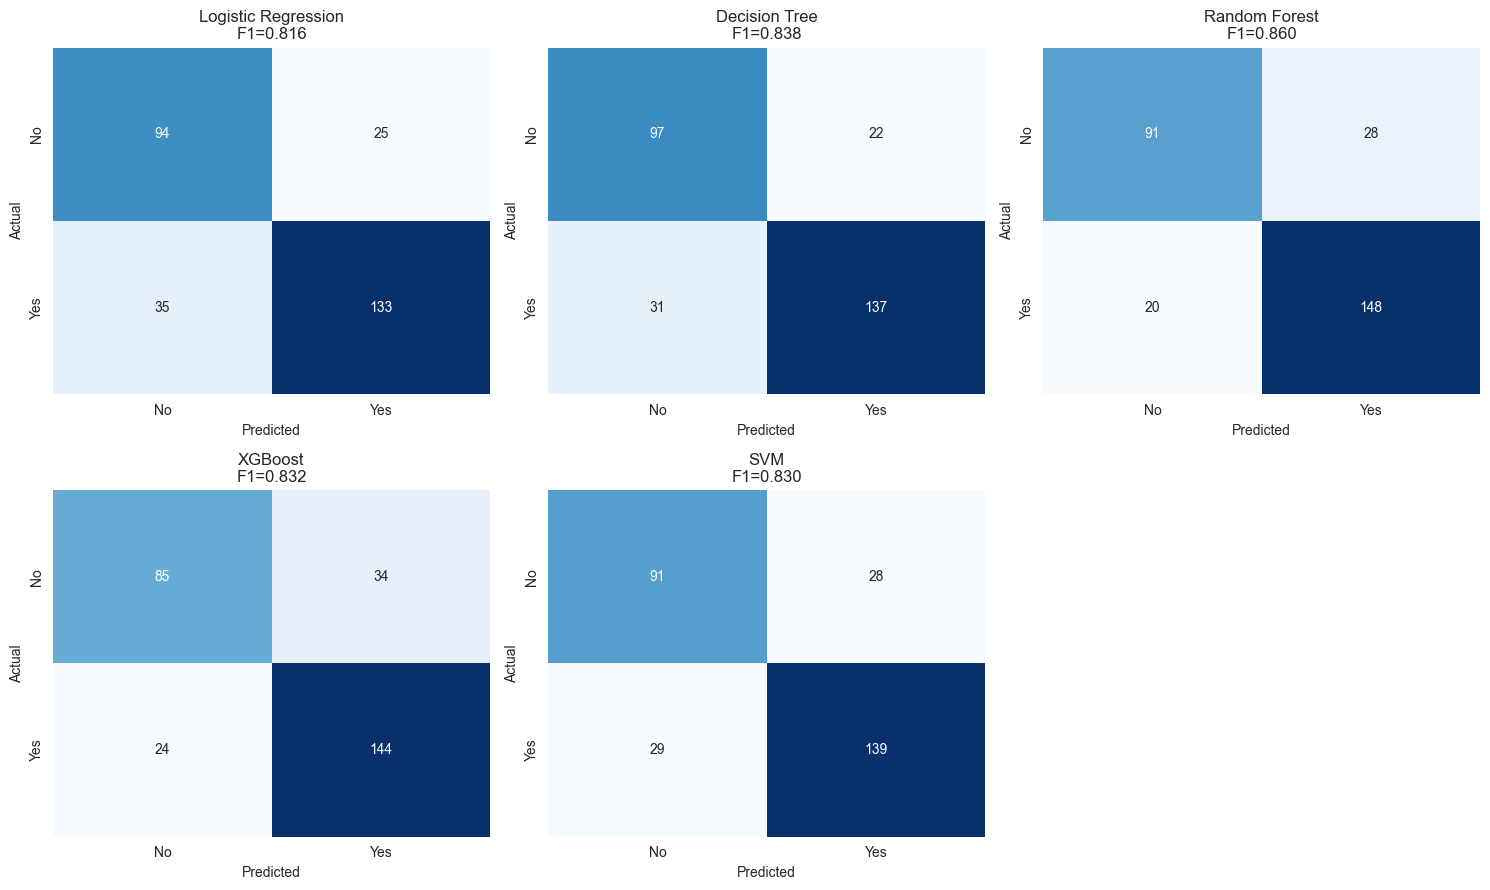

In [27]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()
for i, (name, r) in enumerate(results.items()):
    cm = confusion_matrix(y_test, r['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['No','Yes'], yticklabels=['No','Yes'], cbar=False)
    axes[i].set_title(f"{name}\nF1={r['f1']:.3f}")
    axes[i].set_xlabel('Predicted'); axes[i].set_ylabel('Actual')
axes[-1].axis('off')
plt.tight_layout(); plt.show()

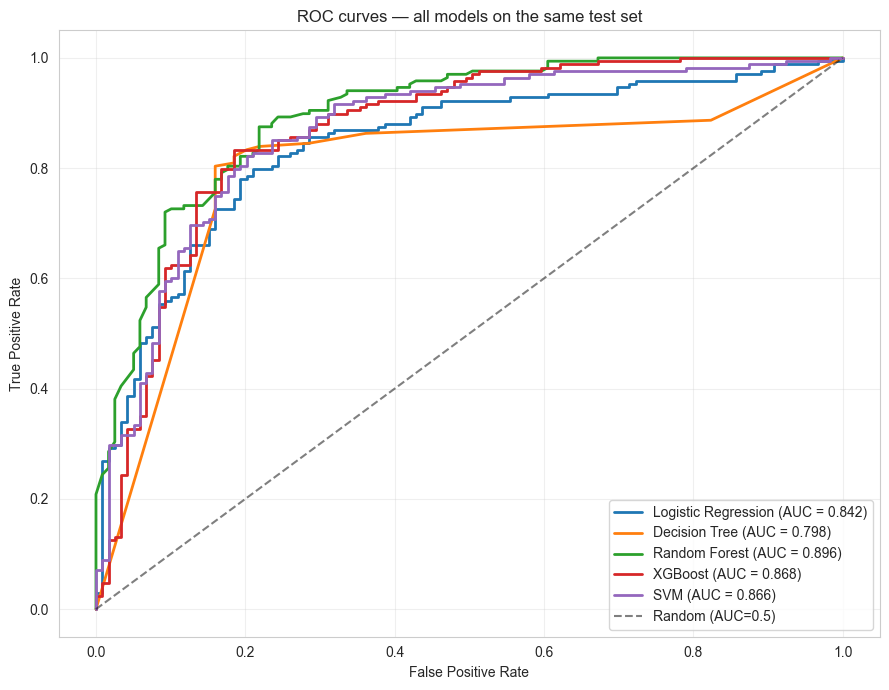

In [28]:
plt.figure(figsize=(9,7))
for name, r in results.items():
    fpr, tpr, _ = roc_curve(y_test, r['y_proba'])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC = {roc_auc:.3f})')
    results[name]['auc'] = roc_auc

plt.plot([0,1], [0,1], 'k--', alpha=0.5, label='Random (AUC=0.5)')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC curves — all models on the same test set')
plt.legend(loc='lower right'); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

In [29]:
final = pd.DataFrame({
    name: {'Accuracy': r['accuracy'], 'Precision': r['precision'],
           'Recall': r['recall'], 'F1': r['f1'], 'AUC': r['auc']}
    for name, r in results.items()
}).T.round(4).sort_values('F1', ascending=False)

print("=" * 60)
print("FINAL RANKING (sorted by F1 score)")
print("=" * 60)
print(final)

winner = final['F1'].idxmax()
print(f"\n🏆 BEST MODEL: {winner}")
print(f"   F1={final.loc[winner,'F1']:.4f} | AUC={final.loc[winner,'AUC']:.4f}")

FINAL RANKING (sorted by F1 score)
                     Accuracy  Precision  Recall      F1     AUC
Random Forest          0.8328     0.8409  0.8810  0.8605  0.8964
Decision Tree          0.8153     0.8616  0.8155  0.8379  0.7984
XGBoost                0.7979     0.8090  0.8571  0.8324  0.8682
SVM                    0.8014     0.8323  0.8274  0.8299  0.8662
Logistic Regression    0.7909     0.8418  0.7917  0.8160  0.8423

🏆 BEST MODEL: Random Forest
   F1=0.8605 | AUC=0.8964


In [30]:
# From bivariate analysis and correlation we found these are the strong predictors.
# Now lets train on THESE only 

top_features = [
    'past_disorder',          
    'current_disorder',       
    'family_history',         
    'work_interfere_treated', 
    'work_interfere_untreated',
    'gender',                 
    'care_options',          
    'benefits',             
    'leave',                
    'anonymity'               
]

print(f"Training on {len(top_features)} selected features that was found out from analysis")
print(top_features)

Training on 10 selected features that was found out from analysis
['past_disorder', 'current_disorder', 'family_history', 'work_interfere_treated', 'work_interfere_untreated', 'gender', 'care_options', 'benefits', 'leave', 'anonymity']


In [31]:
X_selected = df_enc[top_features]
X_all      = df_enc.drop('treatment', axis=1)
y          = df_enc['treatment']

print(f"Selected features : {X_selected.shape[1]}")
print(f"All features      : {X_all.shape[1]}")
print(f"Reduction         : {X_all.shape[1] - X_selected.shape[1]} features dropped")

Selected features : 10
All features      : 31
Reduction         : 21 features dropped


In [32]:
X_tr_sel, X_te_sel, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42, stratify=y
)


X_tr_all, X_te_all, _, _ = train_test_split(
    X_all, y, test_size=0.2, random_state=42, stratify=y
)


scaler_sel = StandardScaler()
X_tr_sel_sc = scaler_sel.fit_transform(X_tr_sel)
X_te_sel_sc  = scaler_sel.transform(X_te_sel)

scaler_all = StandardScaler()
X_tr_all_sc = scaler_all.fit_transform(X_tr_all)
X_te_all_sc  = scaler_all.transform(X_te_all)

print(f"Train: {X_tr_sel.shape} | Test: {X_te_sel.shape}")
print(f"Target balance — Train: {y_train.mean():.2f} | Test: {y_test.mean():.2f}")

Train: (1146, 10) | Test: (287, 10)
Target balance — Train: 0.59 | Test: 0.59


In [33]:
results_sel = {}
results_all = {}

def train_and_eval(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    y_pred  = model.predict(X_te)
    y_proba = (model.predict_proba(X_te)[:,1] 
               if hasattr(model, 'predict_proba') 
               else model.decision_function(X_te))
    return {
        'model'    : model,
        'y_pred'   : y_pred,
        'y_proba'  : y_proba,
        'accuracy' : accuracy_score(y_te, y_pred),
        'precision': precision_score(y_te, y_pred),
        'recall'   : recall_score(y_te, y_pred),
        'f1'       : f1_score(y_te, y_pred),
        'auc'      : auc(*roc_curve(y_te, y_proba)[:2])
    }

models = {
    'Logistic Regression': (LogisticRegression(max_iter=1000, random_state=42), True),
    'Decision Tree'      : (DecisionTreeClassifier(max_depth=8, random_state=42), False),
    'Random Forest'      : (RandomForestClassifier(n_estimators=200, random_state=42), False),
    'XGBoost'            : (XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.1,
                                          eval_metric='logloss', random_state=42), False),
    'SVM'                : (SVC(kernel='rbf', probability=True, random_state=42), True),
}

print("Training on SELECTED features...\n")
for name, (model, needs_scale) in models.items():
    import copy
    m = copy.deepcopy(model)
    Xtr = X_tr_sel_sc if needs_scale else X_tr_sel
    Xte = X_te_sel_sc if needs_scale else X_te_sel
    results_sel[name] = train_and_eval(name, m, Xtr, y_train, Xte, y_test)
    print(f"{name:22s} → Acc:{results_sel[name]['accuracy']:.3f} | "
          f"P:{results_sel[name]['precision']:.3f} | "
          f"R:{results_sel[name]['recall']:.3f} | "
          f"F1:{results_sel[name]['f1']:.3f} | "
          f"AUC:{results_sel[name]['auc']:.3f}")

Training on SELECTED features...

Logistic Regression    → Acc:0.780 | P:0.830 | R:0.786 | F1:0.807 | AUC:0.857
Decision Tree          → Acc:0.836 | P:0.876 | R:0.839 | F1:0.857 | AUC:0.855
Random Forest          → Acc:0.822 | P:0.834 | R:0.869 | F1:0.851 | AUC:0.898
XGBoost                → Acc:0.808 | P:0.847 | R:0.821 | F1:0.834 | AUC:0.907
SVM                    → Acc:0.833 | P:0.845 | R:0.875 | F1:0.860 | AUC:0.893


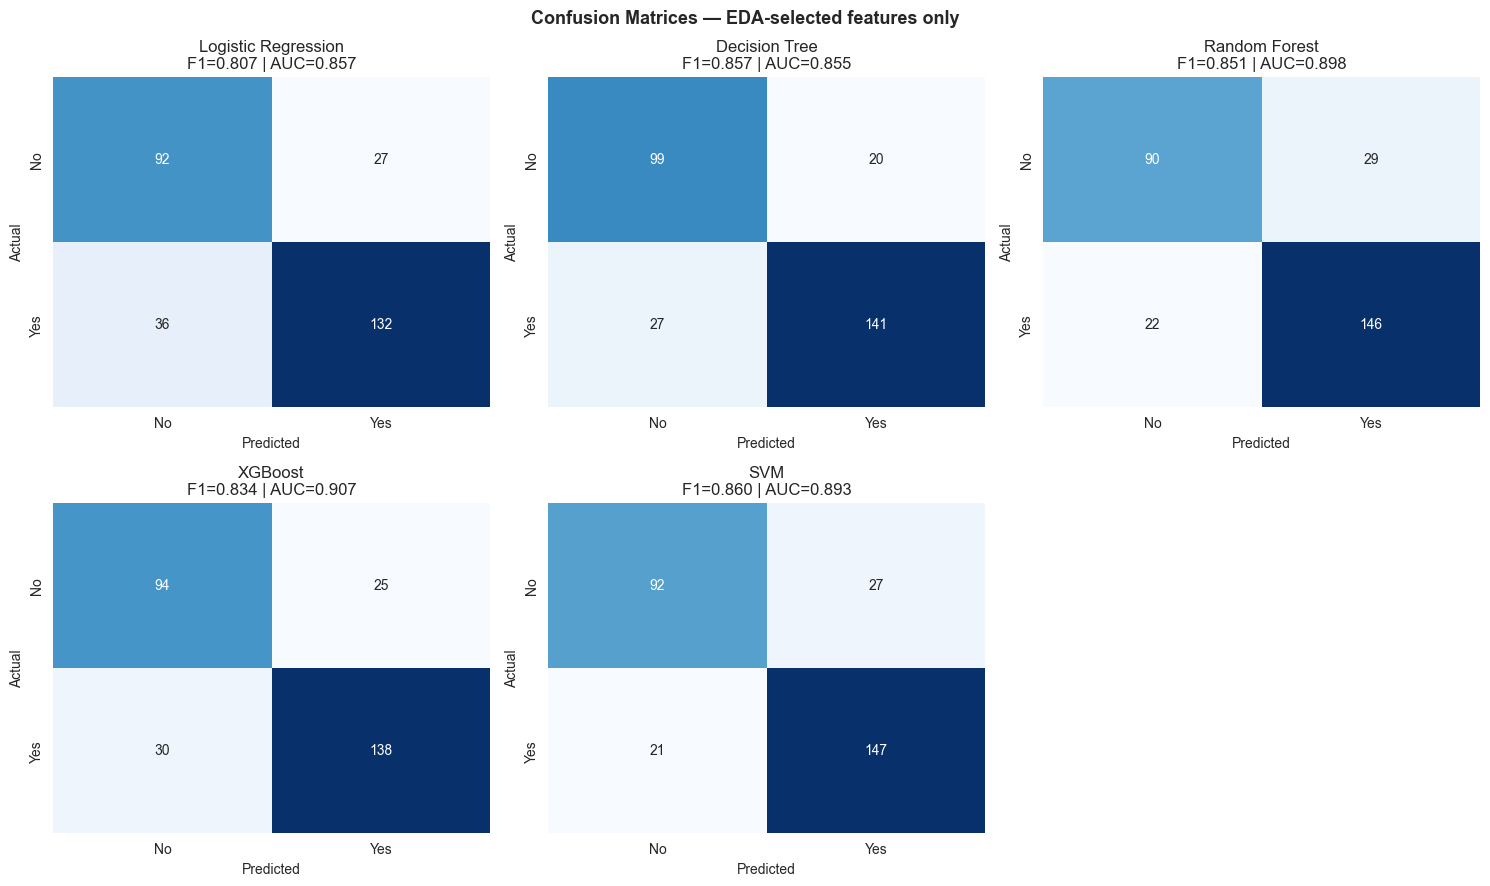

In [34]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, (name, r) in enumerate(results_sel.items()):
    cm = confusion_matrix(y_test, r['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['No','Yes'], yticklabels=['No','Yes'], cbar=False)
    axes[i].set_title(f"{name}\nF1={r['f1']:.3f} | AUC={r['auc']:.3f}")
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

axes[-1].axis('off')
plt.suptitle('Confusion Matrices — EDA-selected features only', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

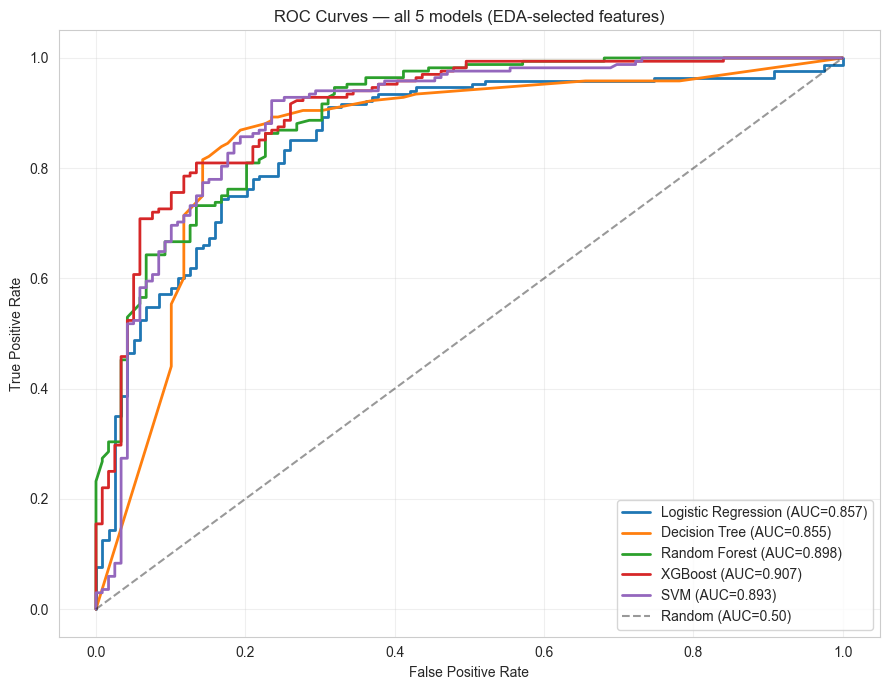

In [35]:
plt.figure(figsize=(9, 7))

for name, r in results_sel.items():
    fpr, tpr, _ = roc_curve(y_test, r['y_proba'])
    plt.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC={r['auc']:.3f})")

plt.plot([0,1],[0,1], 'k--', alpha=0.4, label='Random (AUC=0.50)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — all 5 models (EDA-selected features)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Training on ALL features for comparison...

                     F1 (selected)  F1 (all feats)    Δ F1  AUC (selected)  \
Model                                                                        
Logistic Regression         0.8073          0.8160 -0.0086          0.8567   
Decision Tree               0.8571          0.8379  0.0192          0.8555   
Random Forest               0.8513          0.8605 -0.0092          0.8976   
XGBoost                     0.8338          0.8324  0.0015          0.9074   
SVM                         0.8596          0.8299  0.0298          0.8927   

                     AUC (all feats)  
Model                                 
Logistic Regression           0.8423  
Decision Tree                 0.7984  
Random Forest                 0.8964  
XGBoost                       0.8682  
SVM                           0.8662  


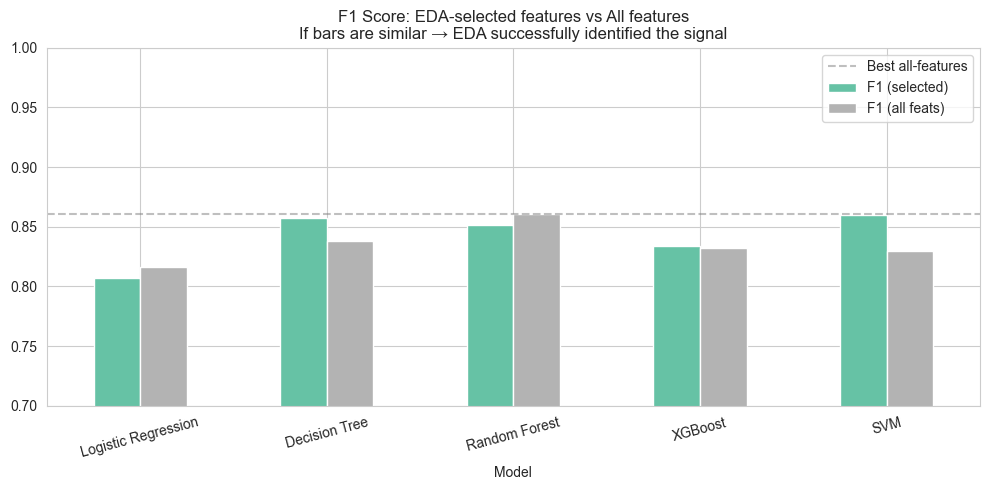

In [36]:
# Training all features version for comparison
print("Training on ALL features for comparison...\n")
for name, (model, needs_scale) in models.items():
    import copy
    m = copy.deepcopy(model)
    Xtr = X_tr_all_sc if needs_scale else X_tr_all
    Xte = X_te_all_sc if needs_scale else X_te_all
    results_all[name] = train_and_eval(name, m, Xtr, y_train, Xte, y_test)

# Building comparison table
rows = []
for name in models:
    rows.append({
        'Model'         : name,
        'F1 (selected)' : results_sel[name]['f1'],
        'F1 (all feats)': results_all[name]['f1'],
        'Δ F1'          : results_sel[name]['f1'] - results_all[name]['f1'],
        'AUC (selected)': results_sel[name]['auc'],
        'AUC (all feats)': results_all[name]['auc'],
    })

comparison = pd.DataFrame(rows).set_index('Model').round(4)
print(comparison)

# Plotting the graph
comparison[['F1 (selected)', 'F1 (all feats)']].plot(
    kind='bar', figsize=(10,5), colormap='Set2'
)
plt.title('F1 Score: EDA-selected features vs All features\n'
          'If bars are similar → EDA successfully identified the signal')
plt.xticks(rotation=15)
plt.ylim(0.7, 1.0)
plt.axhline(comparison['F1 (all feats)'].max(), 
            color='gray', linestyle='--', alpha=0.5, label='Best all-features')
plt.legend()
plt.tight_layout()
plt.show()

In [37]:
final = pd.DataFrame({
    name: {
        'Accuracy' : results_sel[name]['accuracy'],
        'Precision': results_sel[name]['precision'],
        'Recall'   : results_sel[name]['recall'],
        'F1'       : results_sel[name]['f1'],
        'AUC'      : results_sel[name]['auc']
    }
    for name in results_sel
}).T.round(4).sort_values('F1', ascending=False)

print("=" * 55)
print("FINAL RANKING — EDA-selected features (sorted by F1)")
print("=" * 55)
print(final)

winner     = final['F1'].idxmax()
runner_up  = final['F1'].index[1]
f1_gap     = final.loc[winner,'F1'] - final.loc[runner_up,'F1']

print(f"\n Winner  : {winner}")
print(f"   F1      : {final.loc[winner,'F1']:.4f}")
print(f"   AUC     : {final.loc[winner,'AUC']:.4f}")
print(f"\n Runner-up: {runner_up}")
print(f"   Gap from winner: {f1_gap:.4f}")
print(f"\n Features used: {len(top_features)} (down from {X_all.shape[1]})")

FINAL RANKING — EDA-selected features (sorted by F1)
                     Accuracy  Precision  Recall      F1     AUC
SVM                    0.8328     0.8448  0.8750  0.8596  0.8927
Decision Tree          0.8362     0.8758  0.8393  0.8571  0.8555
Random Forest          0.8223     0.8343  0.8690  0.8513  0.8976
XGBoost                0.8084     0.8466  0.8214  0.8338  0.9074
Logistic Regression    0.7805     0.8302  0.7857  0.8073  0.8567

 Winner  : SVM
   F1      : 0.8596
   AUC     : 0.8927

 Runner-up: Decision Tree
   Gap from winner: 0.0025

 Features used: 10 (down from 31)
